## Liberia Health Facilities Visualization Project in Python

In [50]:
#import the libraries
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import folium
%matplotlib inline

In [51]:
#read in the data from a csv file using pandas library
hfdf=pd.read_csv("healthFacilitiesClean.csv")
hfdf.head()

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
0,0,Liberia,2014-08-19 00:00:00,Bonjeh clinic,1 Public Clinic,Bomi,Gbonje (Bonjeh),6.488652,-10.853673,"Bonjeh clinic, Bomi"
1,1,Liberia,2014-08-19 00:00:00,Jenneh #3 clinic,1 Public Clinic,Bomi,Jenne,6.537350,-10.853200,"Jenneh #3 clinic, Bomi"
2,2,Liberia,2014-08-19 00:00:00,Beh Town clinic,1 Public Clinic,Bomi,Beh (Beang),6.617461,-10.987152,"Beh Town clinic, Bomi"
3,3,Liberia,NaN,Bowein clinic,1 Gov. Hospital,Bomi,Bowein,6.607968,-10.870479,"Bowein clinic, Bomi"
4,4,Liberia,NaN,Dagweh Clinic,1 Public Clinic,Bomi,"Tagweh (Dagweh, Togee)",6.566993,-10.946269,"Dagweh Clinic, Bomi"


In [52]:
#count the type of unique health facilities we have in the dataframe
hfdf.Type.value_counts()

Clinic                    500
Health Center              45
Hospital                   39
1 Public Clinic            38
Hosp                        7
GP? TBC                     6
HC                          4
Ebola Treatment Center      3
Clinic?                     2
1 Gov. Hospital             2
ETC                         2
Triage                      2
Clinic (HC)                 1
Animal clinic               1
GP? - TBC                   1
Cinic                       1
ETU                         1
8 beds                      1
Clinic (?)                  1
Dentist? TBC                1
Name: Type, dtype: int64

In [53]:
#replace all "1 Gov. Hospital" with "Gov. Hospital"
hfdf.Type.replace("1 Gov. Hospital","Gov. Hospital",inplace=True)
#replace "1 Public Clinic" with "Public Clinic"
hfdf.Type.replace("1 Public Clinic","Public Clinic",inplace=True)
#replace "Hosp" With "Hospital"
hfdf.Type.replace("Hosp","Hospital",inplace=True)
#replace "GP? TBC" with "TBC"
hfdf.Type.replace("GP? TBC","TBC",inplace=True)
#replace "GP? -TBC" with "TBC"
hfdf.Type.replace("TGP? - TBC","TBC",inplace=True)
hfdf.Type.replace("Clinic?","Clinic",inplace=True)
hfdf.Type.replace("ETC?","ETC",inplace=True)
hfdf.Type.replace("Dentist? TBC","TBC",inplace=True)
hfdf.Type.replace("8 beds","Clinic",inplace=True)
hfdf.Type.replace("Clinic (?)","Clinic",inplace=True)
hfdf.Type.replace("Cinic","Clinic",inplace=True)
hfdf.Type.replace("GP? - TBC","TBC",inplace=True)
hfdf.Type.replace("Clinic (HC)","Clinic",inplace=True)
hfdf.Type.replace("ETU","ETC",inplace=True)
hfdf.Type.replace("HC","Health Center",inplace=True)
#Count unique Entries again
hfdf.Type.value_counts()

Clinic                    506
Health Center              49
Hospital                   46
Public Clinic              38
TBC                         8
Ebola Treatment Center      3
ETC                         3
Gov. Hospital               2
Triage                      2
Animal clinic               1
Name: Type, dtype: int64

In [54]:
hfdf.head()

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
0,0,Liberia,2014-08-19 00:00:00,Bonjeh clinic,Public Clinic,Bomi,Gbonje (Bonjeh),6.488652,-10.853673,"Bonjeh clinic, Bomi"
1,1,Liberia,2014-08-19 00:00:00,Jenneh #3 clinic,Public Clinic,Bomi,Jenne,6.537350,-10.853200,"Jenneh #3 clinic, Bomi"
2,2,Liberia,2014-08-19 00:00:00,Beh Town clinic,Public Clinic,Bomi,Beh (Beang),6.617461,-10.987152,"Beh Town clinic, Bomi"
3,3,Liberia,NaN,Bowein clinic,Gov. Hospital,Bomi,Bowein,6.607968,-10.870479,"Bowein clinic, Bomi"
4,4,Liberia,NaN,Dagweh Clinic,Public Clinic,Bomi,"Tagweh (Dagweh, Togee)",6.566993,-10.946269,"Dagweh Clinic, Bomi"


In [55]:
#fill in the NAN values with using pandas fillna function with the forward fill parameter
hfdf.fillna(method='ffill', inplace=True)
hfdf.head()

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
0,0,Liberia,2014-08-19 00:00:00,Bonjeh clinic,Public Clinic,Bomi,Gbonje (Bonjeh),6.488652,-10.853673,"Bonjeh clinic, Bomi"
1,1,Liberia,2014-08-19 00:00:00,Jenneh #3 clinic,Public Clinic,Bomi,Jenne,6.537350,-10.853200,"Jenneh #3 clinic, Bomi"
2,2,Liberia,2014-08-19 00:00:00,Beh Town clinic,Public Clinic,Bomi,Beh (Beang),6.617461,-10.987152,"Beh Town clinic, Bomi"
3,3,Liberia,2014-08-19 00:00:00,Bowein clinic,Gov. Hospital,Bomi,Bowein,6.607968,-10.870479,"Bowein clinic, Bomi"
4,4,Liberia,2014-08-19 00:00:00,Dagweh Clinic,Public Clinic,Bomi,"Tagweh (Dagweh, Togee)",6.566993,-10.946269,"Dagweh Clinic, Bomi"


In [56]:
#check the dimention of the dataframe (the # of rows and # of columns)
hfdf.shape

(789, 10)

In [57]:
#check simple summary statistics for the categorical variables
hfdf.describe(include="object")

,Country,Date,Center,Type,Region,Place,Location_des
count,789,789,789,789,789,789,789
unique,1,514,776,10,15,409,778
top,Liberia,2014-08-19 00:00:00,West Point holding unit,Clinic,Montserrado,Monrovia,"West Point holding unit, Montserrado"
freq,789,259,5,623,202,85,5


In [58]:
#check simple summary statistics for the continues/numerical variables
hfdf.describe()

,Unnamed: 0,Lat,Long
count,789.000000,789.000000,789.000000
mean,394.000000,809.549791,-10.005524
std,227.908973,22558.592821,4.248701
min,0.000000,4.363740,-101.706690
25%,197.000000,6.113460,-10.751800
50%,394.000000,6.357860,-10.095150
75%,591.000000,6.976060,-8.969808
max,788.000000,633658.000000,6.853972


In [59]:
hfdf.dtypes

Unnamed: 0        int64
Country          object
Date             object
Center           object
Type             object
Region           object
Place            object
Lat             float64
Long            float64
Location_des     object
dtype: object

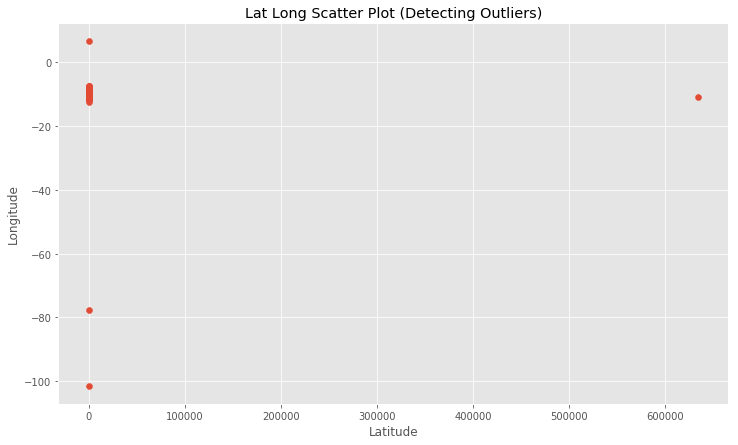

In [60]:
plt.figure(figsize=(12,7))
plt.scatter(hfdf.Lat,hfdf.Long)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Lat Long Scatter Plot (Detecting Outliers)")
plt.show()

In [61]:
hfdf[hfdf["Long"]<(-20)]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
411,411,Liberia,2015-01-01 00:00:00,Yediaken,Clinic,Maryland,Manolu,4.67669,-77.66456,"Yediaken, Maryland"
585,585,Liberia,2015-06-24 00:00:00,JDJ Women&Children,Hospital,Montserrado,Zohulong,6.30302,-101.70669,"JDJ Women&Children, Montserrado"


In [62]:
#correct the outliers longiture entries
hfdf['Long'].replace(-77.66456,-7.66456,inplace=True)

In [63]:
hfdf[hfdf["Long"]<(-20)]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
585,585,Liberia,2015-06-24 00:00:00,JDJ Women&Children,Hospital,Montserrado,Zohulong,6.30302,-101.70669,"JDJ Women&Children, Montserrado"


In [64]:
hfdf.Long.replace(-101.70669000000001,-10.70669,inplace=True)

In [65]:
hfdf.iloc[585]['Long']

-10.70669

In [66]:
hfdf[hfdf["Long"]>(0)]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
166,166,Liberia,2014-08-19 00:00:00,Gargar Clinic,Public Clinic,Grand Cape Mount,Zaway,6.853972,6.853972,"Gargar Clinic, Grand Cape Mount"


In [67]:
hfdf.Long.replace(6.853972,-6.853972,inplace=True)


In [68]:
hfdf.iloc[166]["Long"]

6.853972355

In [69]:
hfdf.Long.replace(6.853972355,-6.853972,inplace=True)

In [70]:
hfdf[hfdf['Lat']>5000]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
486,486,Liberia,2015-03-17 00:00:00,Iron Factory Community,Clinic,Montserrado,Monrovia,633658.0,-10.76251,"Iron Factory Community, Montserrado"


In [71]:
hfdf['Lat'].replace(633658.0,6.33658,inplace=True)

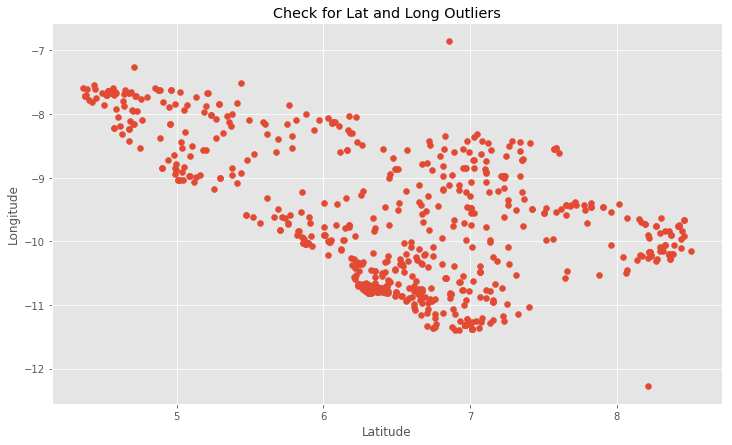

In [72]:
plt.figure(figsize=(12,7))
plt.scatter(hfdf.Lat,hfdf.Long)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Check for Lat and Long Outliers")
plt.show()

In [73]:
hfdf[hfdf['Long']<-12]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
284,284,Liberia,2014-08-27 00:00:00,Lamgbamba,Clinic,Lofa,Yegbedu Town,8.2159,-12.27502,"Lamgbamba, Lofa"


In [74]:
hfdf['Long'].replace(-12.27502,-10.27502, inplace=True)

In [75]:
hfdf[hfdf['Long']>-7]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
166,166,Liberia,2014-08-19 00:00:00,Gargar Clinic,Public Clinic,Grand Cape Mount,Zaway,6.853972,-6.853972,"Gargar Clinic, Grand Cape Mount"


In [76]:
hfdf.drop([166],inplace=True)

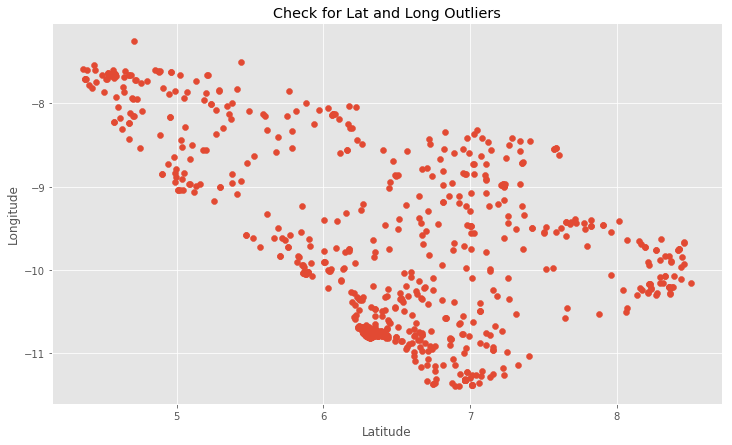

In [77]:
plt.figure(figsize=(12,7))
plt.scatter(hfdf.Lat,hfdf.Long)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Check for Lat and Long Outliers")
plt.show()

In [78]:
liblat=hfdf['Lat'].mean()
liblong=hfdf["Long"].mean()
#get the latituts from the dataframe
lats=list(hfdf['Lat'])
#get the longitudes from the dataframe
longs=list(hfdf['Long'])
#get the healths centers names and Locations
hcdescriptions=list(hfdf["Location_des"])
#get the type of health center
htype=list(hfdf['Type'])
print(liblat,liblong)

6.441964577243657 -9.820066368133245


In [79]:
#find the lat, long mean to the center lat, Long of liberia.
#to cender the map at the point
liblat=hfdf['Lat'].mean()
liblong=hfdf["Long"].mean()
#get the latituts from the dataframe
lats=list(hfdf['Lat'])
#get the longitudes from the dataframe
longs=list(hfdf['Long'])
#get the healths centers names and Locations
hcdescriptions=list(hfdf["Location_des"])
#plot the folium map with the points
hcmap=folium.Map(location=[liblat, liblong],zoom_start=7)

#create a future group
hCenters=folium.FeatureGroup()

#plot the health facilities on the map using a loop
for hlat,hlong,hname in zip(lats,longs,hcdescriptions):
    pname=folium.Popup(html=hname,parse_html=True)
    folium.Marker(
    location=[hlat, hlong],
    popup=pname,
    icon=folium.Icon(color='green', icon='ok-sign'),
).add_to(hCenters)

hcmap.add_child(hCenters)
hcmap.save("FirstMap.html")
hcmap


In [80]:
hfdf[hfdf["Location_des"]=="Lamgbamba, Lofa"]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
284,284,Liberia,2014-08-27 00:00:00,Lamgbamba,Clinic,Lofa,Yegbedu Town,8.2159,-10.27502,"Lamgbamba, Lofa"


In [81]:
hfdf.drop([284], inplace=True)

In [82]:
hfdf[hfdf["Location_des"]=="Gargar Clinic, Grand Cape Mount"]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des


In [83]:
hfdf[hfdf["Location_des"]=="Henriesville City Clinic, Grand Kru"]

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
257,257,Liberia,2014-08-19 00:00:00,Henriesville City Clinic,Clinic,Grand Kru,Grand Cess City,4.7086,-7.257292,"Henriesville City Clinic, Grand Kru"


In [84]:
hfdf.drop([257], inplace=True)

In [85]:
liblat=hfdf['Lat'].mean()
liblong=hfdf["Long"].mean()
#get the latituts from the dataframe
lats=list(hfdf['Lat'])
#get the longitudes from the dataframe
longs=list(hfdf['Long'])
#get the healths centers names and Locations
hcdescriptions=list(hfdf["Location_des"])
#get the type of health center
htype=list(hfdf['Type'])
print(liblat,liblong)

6.44191296039186 -9.822748073872772


In [86]:
hfdf['Region'].value_counts()

Montserrado         202
Lofa                 81
Nimba                70
Grand Cape Mount     63
Grand Bassa          54
Bong                 42
Sinoe                40
Margibi              40
Maryland             40
Bomi                 34
Grand Gedeh          30
River Gee            24
Gbarpolu             24
Grand Kru            22
River Cess           20
Name: Region, dtype: int64

In [87]:
from folium.plugins import MarkerCluster

In [88]:
#plot the folium map with the points
hcmap=folium.Map(location=[liblat, liblong],zoom_start=7)

#get the latituts from the dataframe
lats=list(hfdf['Lat'])
#get the longitudes from the dataframe
longs=list(hfdf['Long'])
#get the healths centers names and Locations
hcdescriptions=list(hfdf["Location_des"])

#create cluster marker
m_cluster=MarkerCluster().add_to(hcmap)

#plot the health facilities on the map using a loop
for hlat,hlong,hname,ht in zip(lats,longs,hcdescriptions,htype):
    pname=folium.Popup(html=hname,parse_html=True)
    #differential the health center markers colors by types
    if ht=="Clinic":
        folium.Marker(
        location=[hlat, hlong],
        popup=pname,
        icon=folium.Icon(color='green', icon='ok-sign'),
    ).add_to(m_cluster)
    elif ht=="Health Center":
        folium.Marker(
        location=[hlat, hlong],
        popup=pname,
        icon=folium.Icon(color='red', icon='ok-sign'),
    ).add_to(m_cluster)
    elif ht=="Hospital":
        folium.Marker(
        location=[hlat, hlong],
        popup=pname,
        icon=folium.Icon(color='black', icon='ok-sign'),
    ).add_to(m_cluster)
    else:
        folium.Marker(
        location=[hlat, hlong],
        popup=pname,
        icon=folium.Icon(color='blue', icon='ok-sign'),
    ).add_to(m_cluster)
        
hcmap.save("clustermap.html")
hcmap.save("clustermap.png")

hcmap


In [89]:
hfdf.head()

,Unnamed: 0,Country,Date,Center,Type,Region,Place,Lat,Long,Location_des
0,0,Liberia,2014-08-19 00:00:00,Bonjeh clinic,Public Clinic,Bomi,Gbonje (Bonjeh),6.488652,-10.853673,"Bonjeh clinic, Bomi"
1,1,Liberia,2014-08-19 00:00:00,Jenneh #3 clinic,Public Clinic,Bomi,Jenne,6.537350,-10.853200,"Jenneh #3 clinic, Bomi"
2,2,Liberia,2014-08-19 00:00:00,Beh Town clinic,Public Clinic,Bomi,Beh (Beang),6.617461,-10.987152,"Beh Town clinic, Bomi"
3,3,Liberia,2014-08-19 00:00:00,Bowein clinic,Gov. Hospital,Bomi,Bowein,6.607968,-10.870479,"Bowein clinic, Bomi"
4,4,Liberia,2014-08-19 00:00:00,Dagweh Clinic,Public Clinic,Bomi,"Tagweh (Dagweh, Togee)",6.566993,-10.946269,"Dagweh Clinic, Bomi"


In [90]:
#group the health facilities by counties and the the total hospital in each country
counties_health_centers=hfdf[['Region',"Center"]]
counties_health_centers.head()

,Region,Center
0,Bomi,Bonjeh clinic
1,Bomi,Jenneh #3 clinic
2,Bomi,Beh Town clinic
3,Bomi,Bowein clinic
4,Bomi,Dagweh Clinic


In [91]:
counties_health_centersgr=counties_health_centers.groupby(by='Region',axis=0).count()
counties_health_centersgr.head()

,Center
Region,
Bomi,34
Bong,42
Gbarpolu,24
Grand Bassa,54
Grand Cape Mount,63


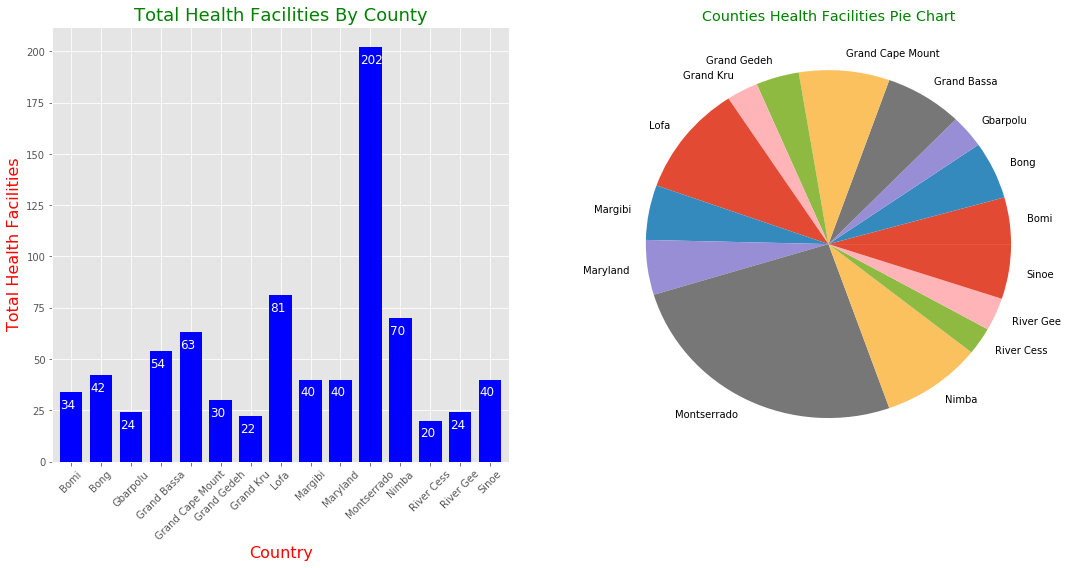

In [92]:
plt.style.use("ggplot")
fig=plt.figure(figsize=(18,8))
ax1=plt.subplot(1,2,1)
counties_health_centersgr.plot(kind="bar",legend=None,rot=45,
                                  color=[['b']],width=0.75, ax=ax1)
plt.title("Total Health Facilities By County",fontsize=18,color="g")
plt.xlabel("Country", fontsize=16, color="r")
plt.ylabel("Total Health Facilities", fontsize=16, color="r")
for i,t in enumerate(counties_health_centersgr['Center']):
    plt.annotate(str(t),xy=(float((i-0.35)),float((t-8))),color='w',fontsize=12 )
plt.savefig("Hcbarchart.jpg")
ax2=plt.subplot(1,2,2)
counties_health_centersgr.plot.pie(y='Center',ax=ax2,legend=None)
plt.title("Counties Health Facilities Pie Chart", color="g")
plt.ylabel("")
plt.show()

In [93]:
#group the health centers by county and type
hc_byGT=hfdf[['Region','Type',"Center"]].groupby(by=['Region','Type'],as_index=False).count()
hc_byGT.head()

,Region,Type,Center
0,Bomi,Clinic,12
1,Bomi,Gov. Hospital,1
2,Bomi,Hospital,3
3,Bomi,Public Clinic,18
4,Bong,Clinic,39


In [94]:
hc_byGT2=hc_byGT.pivot(columns='Type',index='Region',values='Center')
hc_byGT2

Type,Animal clinic,Clinic,ETC,Ebola Treatment Center,Gov. Hospital,Health Center,Hospital,Public Clinic,TBC,Triage
Region,,,,,,,,,,
Bomi,NaN,12.0,NaN,NaN,1.0,NaN,3.0,18.0,NaN,NaN
Bong,NaN,39.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN
Gbarpolu,NaN,21.0,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN
Grand Bassa,NaN,48.0,NaN,NaN,NaN,1.0,5.0,NaN,NaN,NaN
Grand Cape Mount,1.0,33.0,NaN,NaN,1.0,2.0,1.0,17.0,8.0,NaN
Grand Gedeh,NaN,26.0,NaN,NaN,NaN,3.0,1.0,NaN,NaN,NaN
Grand Kru,NaN,15.0,1.0,NaN,NaN,5.0,1.0,NaN,NaN,NaN
Lofa,NaN,67.0,2.0,NaN,NaN,7.0,5.0,NaN,NaN,NaN
Margibi,NaN,30.0,NaN,NaN,NaN,8.0,2.0,NaN,NaN,NaN


In [95]:
#fill in the nan with 0
hc_byGT2.fillna(0,inplace=True)
hc_byGT2

Type,Animal clinic,Clinic,ETC,Ebola Treatment Center,Gov. Hospital,Health Center,Hospital,Public Clinic,TBC,Triage
Region,,,,,,,,,,
Bomi,0.0,12.0,0.0,0.0,1.0,0.0,3.0,18.0,0.0,0.0
Bong,0.0,39.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
Gbarpolu,0.0,21.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0
Grand Bassa,0.0,48.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0
Grand Cape Mount,1.0,33.0,0.0,0.0,1.0,2.0,1.0,17.0,8.0,0.0
Grand Gedeh,0.0,26.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0
Grand Kru,0.0,15.0,1.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0
Lofa,0.0,67.0,2.0,0.0,0.0,7.0,5.0,0.0,0.0,0.0
Margibi,0.0,30.0,0.0,0.0,0.0,8.0,2.0,0.0,0.0,0.0


In [96]:
col=list(hc_byGT2.columns)
row=list(hc_byGT2.index.values)
print(col, row)
hc_byGT2["Clinic"]["Bomi"]


['Animal clinic', 'Clinic', 'ETC', 'Ebola Treatment Center', 'Gov. Hospital', 'Health Center', 'Hospital', 'Public Clinic', 'TBC', 'Triage'] ['Bomi', 'Bong', 'Gbarpolu', 'Grand Bassa', 'Grand Cape Mount', 'Grand Gedeh', 'Grand Kru', 'Lofa', 'Margibi', 'Maryland', 'Montserrado', 'Nimba', 'River Cess', 'River Gee', 'Sinoe']


12.0

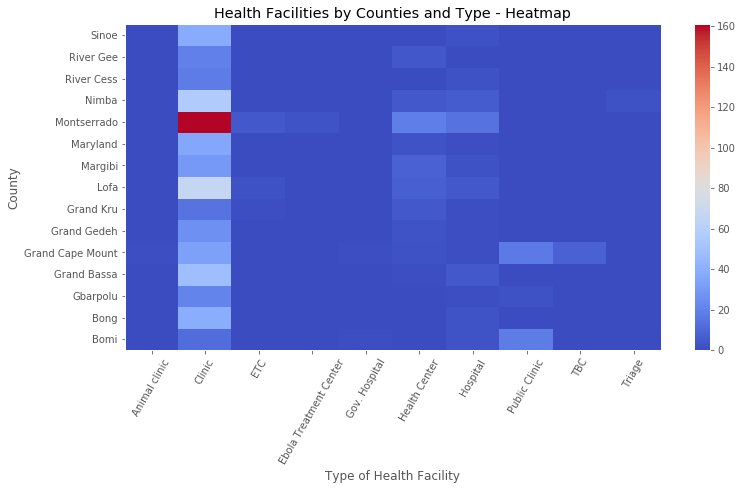

In [97]:
fig, ax=plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(6)
im=ax.pcolor(hc_byGT2, cmap='coolwarm')
ax2=plt.colorbar(im,ax=ax)

#label names
row_labels=hc_byGT2.columns
col_labels=hc_byGT2.index
#move ticks and labels to the center
ax.set_xticks(np.arange(hc_byGT2.shape[1])+0.5, minor=False)
ax.set_yticks(np.arange(hc_byGT2.shape[0])+0.5, minor=False)
#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)
plt.title("Health Facilities by Counties and Type - Heatmap")
plt.ylabel("County")
plt.xlabel("Type of Health Facility")
#rotate label if too long
plt.xticks(rotation=60)
fig.savefig("hcHeatMap.jpg")
plt.show()